In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [4]:

df = pd.read_csv('AB_NYC_2019.csv')

print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.describe())


(48895, 16)
     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room    149               1           

In [5]:
print("Column names:")
print(df.columns.tolist())


print("\nData types:")
print(df.dtypes)

print("\nTarget variable statistics:")
print(df['price'].describe())

print("\nUnique values in categorical columns:")
print("Room types:",df['room_type'].unique())
print("Neighbourhood groups:",df['neighbourhood_group'].unique())

print("\nNumber of unique values:")
print("Listings:",df['id'].nunique())
print("Hosts:",df['host_id'].nunique())
print("Neighbourhoods:",df['neighbourhood'].nunique())


Column names:
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']

Data types:
id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

Target variable statistics:
cou

In [8]:
print("Zero prices:",(df['price']==0).sum())
print("Negative prices:",(df['price']<0).sum())
print("Prices above 500:",(df['price']>500).sum())
print("Prices above 1000:",(df['price']>1000).sum())
print("Prices above 5000:",(df['price']>5000).sum())

Zero prices: 11
Negative prices: 0
Prices above 500: 1044
Prices above 1000: 239
Prices above 5000: 20


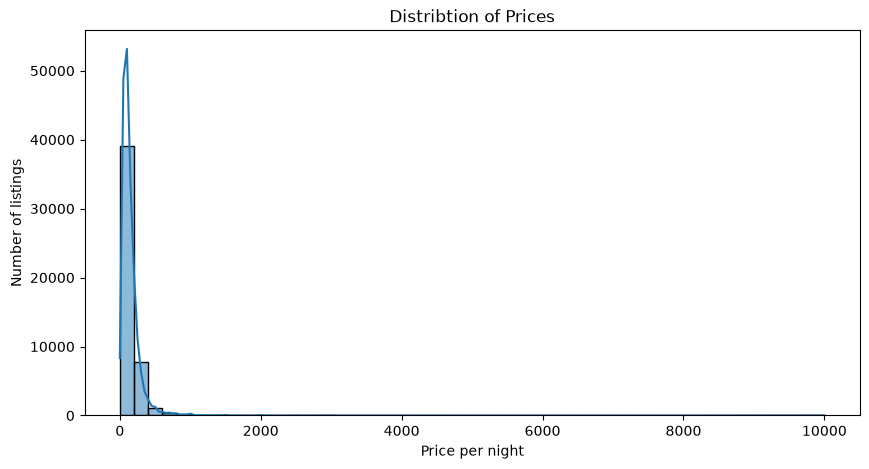

In [12]:
plt.figure(figsize=(10,5))
sns.histplot(df['price'],bins=50,kde=True)

plt.title("Distribtion of Prices")
plt.xlabel("Price per night")
plt.ylabel("Number of listings")
plt.show()


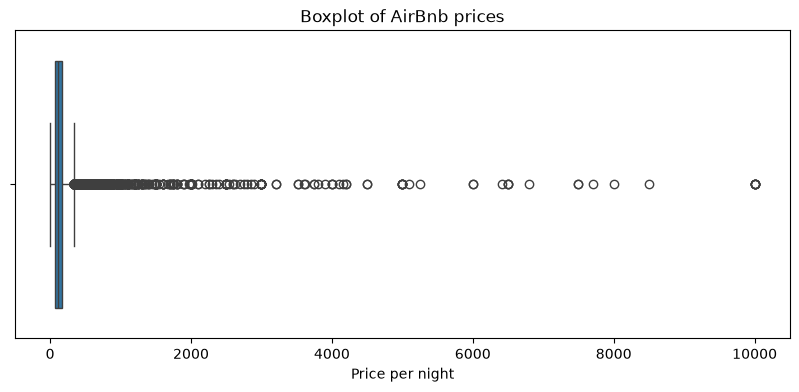

In [14]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df["price"])
plt.title("Boxplot of AirBnb prices")
plt.xlabel("Price per night")

plt.show()


In [17]:
missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

display(missing_summary)

,Missing Values,Missing Percentage
last_review,10052,20.558339
reviews_per_month,10052,20.558339
host_name,21,0.042949
name,16,0.032723
neighbourhood_group,0,0.000000
neighbourhood,0,0.000000
id,0,0.000000
host_id,0,0.000000
longitude,0,0.000000
latitude,0,0.000000


In [18]:
df_clean = df.copy()

columns_to_drop = [
    "id",
    "name",
    "host_name",
    "last_review"
]

df_clean = df_clean.drop(columns=columns_to_drop)

print("Shape after removing unnecessary columns:", df_clean.shape)

display(df_clean.head())

Shape after removing unnecessary columns: (48895, 12)


,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [19]:
print(df_clean.isnull().sum())

host_id                               0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


In [20]:
df_clean["reviews_per_month"] = df_clean["reviews_per_month"].fillna(0)

df_clean = df_clean.dropna(subset=["host_id"])

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

print("Shape after handling missing values:", df_clean.shape)

Missing values after cleaning:
host_id                           0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64
Shape after handling missing values: (48895, 12)


In [21]:
df_clean = df_clean[df_clean["price"] > 0]

print("Shape after removing invalid prices:", df_clean.shape)

print("Minimum price:", df_clean["price"].min())
print("Maximum price:", df_clean["price"].max())

Shape after removing invalid prices: (48884, 12)
Minimum price: 10
Maximum price: 10000


In [22]:
print("Duplicate rows before removal:", df_clean.duplicated().sum())

df_clean = df_clean.drop_duplicates()

print("Duplicate rows after removal:", df_clean.duplicated().sum())

print("Final shape after duplicate removal:", df_clean.shape)
df_clean.to_csv("AB_NYC_2019_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Duplicate rows before removal: 0
Duplicate rows after removal: 0
Final shape after duplicate removal: (48884, 12)
Cleaned dataset saved successfully.


In [23]:
Q1 = df_clean["price"].quantile(0.25)

Q3 = df_clean["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 69.0
Q3: 175.0
IQR: 106.0
Lower bound: -90.0
Upper bound: 334.0


In [24]:
outliers = df_clean[df_clean["price"] > upper_bound]

print("Number of price outliers:", len(outliers))

print("Percentage of price outliers:",
      len(outliers) / len(df_clean) * 100)

Number of price outliers: 2972
Percentage of price outliers: 6.079698878978808


In [25]:
display(
    df_clean[
        [
            "neighbourhood_group",
            "neighbourhood",
            "room_type",
            "price"
        ]
    ]
    .sort_values(by="price", ascending=False)
    .head(20)
)

df_clean = df_clean[
    (df_clean["price"] >= 0) &
    (df_clean["price"] <= upper_bound)
]

print("Shape after removing price outliers:", df_clean.shape)

print("New maximum price:", df_clean["price"].max())

,neighbourhood_group,neighbourhood,room_type,price
9151,Queens,Astoria,Private room,10000
17692,Brooklyn,Greenpoint,Entire home/apt,10000
29238,Manhattan,Upper West Side,Entire home/apt,10000
12342,Manhattan,Lower East Side,Private room,9999
40433,Manhattan,Lower East Side,Entire home/apt,9999
6530,Manhattan,East Harlem,Entire home/apt,9999
30268,Manhattan,Tribeca,Entire home/apt,8500
4377,Brooklyn,Clinton Hill,Entire home/apt,8000
29662,Manhattan,Upper East Side,Entire home/apt,7703
45666,Brooklyn,East Flatbush,Private room,7500


Shape after removing price outliers: (45912, 12)
New maximum price: 334


In [28]:
df_clean["total_review_activity"] = (
    df_clean["number_of_reviews"] *
    df_clean["reviews_per_month"]
)
df_clean["host_type"] = pd.cut(
    df_clean["calculated_host_listings_count"],
    bins=[0, 1, 5, 20, np.inf],
    labels=[
        "Single Listing",
        "Small Host",
        "Medium Host",
        "Large Host"
    ]
)

df_clean["availability_type"] = pd.cut(
    df_clean["availability_365"],
    bins=[-1, 30, 180, 365],
    labels=[
        "Low Availability",
        "Medium Availability",
        "High Availability"
    ]
)

print("Updated columns:")
print(df_clean.columns.tolist())

display(
    df_clean[
        [
            "total_review_activity",
            "host_type",
            "availability_type"
        ]
    ].head()
)

Updated columns:
['host_id', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'total_review_activity', 'host_type', 'availability_type']


,total_review_activity,host_type,availability_type
0,1.89,Medium Host,High Availability
1,17.10,Small Host,High Availability
2,0.00,Single Listing,High Availability
3,1252.80,Single Listing,High Availability
4,0.90,Single Listing,Low Availability


In [29]:
df_clean.to_csv(
    "AB_NYC_2019_prepared.csv",
    index=False
)

print("Prepared dataset saved successfully.")

Prepared dataset saved successfully.


In [30]:
X = df_clean.drop(columns=["price"])

y = df_clean["price"]

print("Input features shape:", X.shape)

print("Target shape:", y.shape)

print("Input features:")
print(X.columns.tolist())

print("\nTarget variable:")
print(y.head())

Input features shape: (45912, 14)
Target shape: (45912,)
Input features:
['host_id', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'total_review_activity', 'host_type', 'availability_type']

Target variable:
0    149
1    225
2    150
3     89
4     80
Name: price, dtype: int64


In [33]:
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['host_id', 'latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'total_review_activity']

Categorical features:
['neighbourhood_group', 'neighbourhood', 'room_type', 'host_type', 'availability_type']


C:\Users\HP\AppData\Local\Temp\ipykernel_1968\1904067735.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training input shape:", X_train.shape)

print("Testing input shape:", X_test.shape)

print("Training target shape:", y_train.shape)

print("Testing target shape:", y_test.shape)

Training input shape: (36729, 14)
Testing input shape: (9183, 14)
Training target shape: (36729,)
Testing target shape: (9183,)


In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [36]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)

print("Processed testing shape:", X_test_processed.shape)

print("Missing values in processed training data:",
      np.isnan(X_train_processed).sum())

print("Missing values in processed testing data:",
      np.isnan(X_test_processed).sum())

Processed training shape: (36729, 241)
Processed testing shape: (9183, 241)
Missing values in processed training data: 0
Missing values in processed testing data: 0


In [37]:
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

linear_model = LinearRegression()

linear_model.fit(
    X_train_processed,
    y_train
)

linear_predictions = linear_model.predict(
    X_test_processed
)

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Results")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R² Score:", linear_r2)

Linear Regression Results
MAE: 33.74081592817929
RMSE: 46.01077501905975
R² Score: 0.5324760202529818


In [38]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_processed,
    y_train
)

random_forest_predictions = random_forest_model.predict(
    X_test_processed
)

random_forest_mae = mean_absolute_error(
    y_test,
    random_forest_predictions
)

random_forest_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        random_forest_predictions
    )
)

random_forest_r2 = r2_score(
    y_test,
    random_forest_predictions
)

print("Random Forest Results")
print("MAE:", random_forest_mae)
print("RMSE:", random_forest_rmse)
print("R² Score:", random_forest_r2)

Random Forest Results
MAE: 31.285345021597884
RMSE: 43.510706651009166
R² Score: 0.5819029848659067


In [39]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        random_forest_mae
    ],
    "RMSE": [
        linear_rmse,
        random_forest_rmse
    ],
    "R2 Score": [
        linear_r2,
        random_forest_r2
    ]
})

display(
    model_results.sort_values(
        by="RMSE",
        ascending=True
    )
)

,Model,MAE,RMSE,R2 Score
1,Random Forest,31.285345,43.510707,0.581903
0,Linear Regression,33.740816,46.010775,0.532476


In [40]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [100, 150, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(
    X_train_processed,
    y_train
)

print("Best parameters:")
print(random_search.best_params_)

print("Best cross-validation RMSE:")
print(-random_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 20}
Best cross-validation RMSE:
44.17857677772378


In [41]:
best_random_forest = random_search.best_estimator_

tuned_predictions = best_random_forest.predict(
    X_test_processed
)

tuned_mae = mean_absolute_error(
    y_test,
    tuned_predictions
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_predictions
    )
)

tuned_r2 = r2_score(
    y_test,
    tuned_predictions
)

print("Tuned Random Forest Results")
print("MAE:", tuned_mae)
print("RMSE:", tuned_rmse)
print("R² Score:", tuned_r2)

Tuned Random Forest Results
MAE: 31.012164967951247
RMSE: 43.106397226546164
R² Score: 0.5896369519112872


In [42]:
final_model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "MAE": [
        linear_mae,
        random_forest_mae,
        tuned_mae
    ],
    "RMSE": [
        linear_rmse,
        random_forest_rmse,
        tuned_rmse
    ],
    "R2 Score": [
        linear_r2,
        random_forest_r2,
        tuned_r2
    ]
})

display(
    final_model_results.sort_values(
        by="RMSE",
        ascending=True
    )
)

,Model,MAE,RMSE,R2 Score
2,Tuned Random Forest,31.012165,43.106397,0.589637
1,Random Forest,31.285345,43.510707,0.581903
0,Linear Regression,33.740816,46.010775,0.532476


In [43]:
import joblib

joblib.dump(
    best_random_forest,
    "airbnb_price_model.pkl"
)

joblib.dump(
    preprocessor,
    "airbnb_preprocessor.pkl"
)

print("Final model saved successfully.")
print("Preprocessor saved successfully.")

Final model saved successfully.
Preprocessor saved successfully.
